# NFHS-5 Health Indicators Analysis

This project analyzes obesity, anaemia, hypertension, and blood sugar across Indian states using NFHS-5 data.

In [ ]:
# ── Step 0: Install dependencies 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import folium
import urllib.request
import json
import warnings

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [3]:
# ── Step 1: Download NFHS-5 State CSV from GitHub ────────────────────────────
DATA_URL = (
    "https://raw.githubusercontent.com/pratapvardhan/NFHS-5/"
    "master/NFHS-5-States.csv"
)
LOCAL_FILE = "NFHS-5-States.csv"

urllib.request.urlretrieve(DATA_URL, LOCAL_FILE)
print(f"✅ Dataset downloaded → {LOCAL_FILE}")

# Load into DataFrame
raw_df = pd.read_csv(LOCAL_FILE)
print(f"Shape: {raw_df.shape}  |  Columns: {list(raw_df.columns)}")
raw_df.head(3)

✅ Dataset downloaded → NFHS-5-States.csv
Shape: (4847, 7)  |  Columns: ['state', 'state_code', 'indicator', 'nfhs5_urban', 'nfhs5_rural', 'nfhs5_total', 'nfhs4_total']


,state,state_code,indicator,nfhs5_urban,nfhs5_rural,nfhs5_total,nfhs4_total
0,India,NaN,1. Female population age 6 years and above who...,82.5,66.8,71.8,68.8
1,India,NaN,2. Population below age 15 years (%),23.1,28.1,26.5,28.6
2,India,NaN,3. Sex ratio of the total population (females ...,985.0,1037.0,1020.0,991.0


In [4]:
# ── Step 2: Inspect the indicator list ──────────────────────────────────────
print("Total unique indicators:", raw_df['indicator'].nunique())
print("\nSample indicators around our area of interest (86–110):")
all_indicators = raw_df['indicator'].unique()
target_range = [i for i in all_indicators
                if any(str(n) + '.' in i for n in range(86, 112))]
for ind in target_range:
    print(" ", ind)

Total unique indicators: 132

Sample indicators around our area of interest (86–110):
  86. Women whose Body Mass Index (BMI) is below normal (BMI <18.5 kg/m2)21 (%)
  87. Men whose Body Mass Index (BMI) is below normal (BMI <18.5 kg/m2) (%)
  88. Women who are overweight or obese (BMI ≥25.0 kg/m2)21 (%)
  89. Men who are overweight or obese (BMI ≥25.0 kg/m2) (%)
  90. Women who have high risk waist-to-hip ratio (≥0.85) (%)
  91. Men who have high risk waist-to-hip ratio (≥0.90) (%)
  92. Children age 6-59 months who are anaemic (<11.0 g/dl)22 (%)
  93. Non-pregnant women age 15-49 years who are anaemic (<12.0 g/dl)22 (%)
  94. Pregnant women age 15-49 years who are anaemic (<11.0 g/dl)22 (%)
  95. All women age 15-49 years who are anaemic22 (%)
  96. All women age 15-19 years who are anaemic22 (%)
  97. Men age 15-49 years who are anaemic (<13.0 g/dl)22 (%)
  98. Men age 15-19 years who are anaemic (<13.0 g/dl)22 (%)
  99. Blood sugar level - high (141-160 mg/dl)23 (%)
  100. Blood su

In [5]:
# ── Step 3: Filter key indicators and pivot to wide format ───────────────────

# Exact indicator strings from the dataset
INDICATOR_MAP = {
    "Obesity_Women":      "88. Women who are overweight or obese (BMI ≥25.0 kg/m2)21 (%)",
    "Obesity_Men":        "89. Men who are overweight or obese (BMI ≥25.0 kg/m2) (%)",
    "Anaemia_Children":   "92. Children age 6-59 months who are anaemic (<11.0 g/dl)22 (%)",
    "Anaemia_Women":      "95. All women age 15-49 years who are anaemic22 (%)",
    "BloodSugar_Women":   "101. Blood sugar level - high or very high (>140 mg/dl) or taking medicine to control blood sugar level23 (%)",
    "BloodSugar_Men":     "104. Blood sugar level - high or very high (>140 mg/dl) or taking medicine to control blood sugar level23 (%)",
    "Hypertension_Women": "107. Elevated blood pressure (Systolic ≥140 mm of Hg and/or Diastolic ≥90 mm of Hg) or taking medicine to control blood pressure (%)",
    "Hypertension_Men":   "110. Elevated blood pressure (Systolic ≥140 mm of Hg and/or Diastolic ≥90 mm of Hg) or taking medicine to control blood pressure (%)",
}

# Filter rows
filtered = raw_df[raw_df['indicator'].isin(INDICATOR_MAP.values())].copy()

# Keep state-level rows only (exclude pan-India row)
filtered = filtered[filtered['state'] != 'India'].copy()

# Use nfhs5_total column
filtered = filtered[['state', 'state_code', 'indicator', 'nfhs5_total']].copy()

# Reverse map: indicator string → short name
inv_map = {v: k for k, v in INDICATOR_MAP.items()}
filtered['metric'] = filtered['indicator'].map(inv_map)

# Pivot to wide format
df = filtered.pivot_table(
    index=['state', 'state_code'],
    columns='metric',
    values='nfhs5_total',
    aggfunc='first'
).reset_index()
df.columns.name = None

print(f"Wide DataFrame shape: {df.shape}")
df.head()

Wide DataFrame shape: (36, 10)


,state,state_code,Anaemia_Children,Anaemia_Women,BloodSugar_Men,BloodSugar_Women,Hypertension_Men,Hypertension_Women,Obesity_Men,Obesity_Women
0,Andaman & Nicobar Islands,AN,40.0,57.5,17.9,17.5,30.2,25.3,45.3,38.1
1,Andhra Pradesh,AP,63.2,58.8,21.8,19.5,29.0,25.3,31.1,36.3
2,Arunachal Pradesh,AR,56.6,40.3,11.9,8.4,33.1,24.9,27.6,23.9
3,Assam,AS,68.4,65.9,16.0,12.8,20.3,19.1,16.2,15.2
4,Bihar,BR,69.4,63.5,16.2,12.7,18.4,15.9,14.7,15.9


In [6]:
# ── Step 3 cont.: Convert to numeric; handle dash placeholders ───────────────
numeric_cols = list(INDICATOR_MAP.keys())

for col in numeric_cols:
    if col in df.columns:
        # Replace any dash / em-dash / non-numeric placeholders with NaN
        df[col] = df[col].astype(str).str.replace(r'[^\d.]', '', regex=True)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# ── Step 4: Create Gender_Obesity_Gap column ─────────────────────────────────
# Positive = women have higher obesity rate than men
df['Gender_Obesity_Gap'] = df['Obesity_Women'] - df['Obesity_Men']

print("Missing values per column:")
print(df[numeric_cols + ['Gender_Obesity_Gap']].isna().sum().to_string())
print()
print("\nSummary statistics:")
df[numeric_cols + ['Gender_Obesity_Gap']].describe().round(2)

Missing values per column:
Obesity_Women         0
Obesity_Men           0
Anaemia_Children      0
Anaemia_Women         0
BloodSugar_Women      0
BloodSugar_Men        0
Hypertension_Women    0
Hypertension_Men      0
Gender_Obesity_Gap    0


Summary statistics:


,Obesity_Women,Obesity_Men,Anaemia_Children,Anaemia_Women,BloodSugar_Women,BloodSugar_Men,Hypertension_Women,Hypertension_Men,Gender_Obesity_Gap
count,36.00,36.00,36.00,36.00,36.00,36.00,36.00,36.00,36.00
mean,27.68,27.55,62.10,53.99,13.86,15.91,22.48,26.22,0.13
std,9.82,9.06,12.20,13.57,4.39,4.34,4.43,6.03,4.72
min,11.50,13.90,39.40,25.80,6.70,8.00,14.90,15.40,-9.50
25%,21.45,19.55,55.20,46.50,10.15,13.58,19.77,21.62,-2.22
50%,28.80,29.30,64.90,54.90,13.60,15.65,22.65,25.40,0.30
75%,35.05,33.05,69.55,62.75,17.50,17.95,24.92,30.30,3.32
max,46.20,45.30,92.50,92.80,24.80,27.00,34.50,41.60,9.60


In [7]:
# Final cleaned DataFrame preview
print("States in dataset:", df['state'].nunique())
df[['state', 'state_code', 'Obesity_Women', 'Obesity_Men',
    'Gender_Obesity_Gap', 'Anaemia_Children', 'Anaemia_Women',
    'Hypertension_Women', 'Hypertension_Men',
    'BloodSugar_Women', 'BloodSugar_Men']].head(10)

States in dataset: 36


,state,state_code,Obesity_Women,Obesity_Men,Gender_Obesity_Gap,Anaemia_Children,Anaemia_Women,Hypertension_Women,Hypertension_Men,BloodSugar_Women,BloodSugar_Men
0,Andaman & Nicobar Islands,AN,38.1,45.3,-7.2,40.0,57.5,25.3,30.2,17.5,17.9
1,Andhra Pradesh,AP,36.3,31.1,5.2,63.2,58.8,25.3,29.0,19.5,21.8
2,Arunachal Pradesh,AR,23.9,27.6,-3.7,56.6,40.3,24.9,33.1,8.4,11.9
3,Assam,AS,15.2,16.2,-1.0,68.4,65.9,19.1,20.3,12.8,16.0
4,Bihar,BR,15.9,14.7,1.2,69.4,63.5,15.9,18.4,12.7,16.2
5,Chandigarh,CH,44.0,34.4,9.6,54.6,60.3,25.0,30.6,19.0,16.6
6,Chhattisgarh,CT,14.1,14.9,-0.8,67.2,60.8,23.6,27.7,9.0,10.8
7,Dadra & Nagar Haveli and Daman & Diu,DD,26.8,21.4,5.4,75.8,62.5,14.9,15.4,13.6,16.4
8,Goa,GA,36.1,32.6,3.5,53.2,39.0,27.5,26.8,20.8,24.1
9,Gujarat,GJ,22.6,19.9,2.7,79.7,65.0,20.6,20.3,15.8,16.9


In [8]:
# ── Task 1: Pearson Correlation Matrix ───────────────────────────────────────
corr_cols = [
    'Anaemia_Children', 'Anaemia_Women',
    'Obesity_Women', 'Obesity_Men',
    'Hypertension_Women', 'Hypertension_Men',
    'BloodSugar_Women', 'BloodSugar_Men',
    'Gender_Obesity_Gap'
]

corr_matrix = df[corr_cols].corr(method='pearson')

# Display Pearson Correlation Matrix
print("=" * 80)
print("Pearson Correlation Matrix (Rounded to 2 Decimal Places)")
print("=" * 80)

corr_display = corr_matrix.round(2)
print(corr_display)

# Key coefficient
r_anaemia_child_vs_obesity_women = corr_matrix.loc[
    'Anaemia_Children', 'Obesity_Women'
]
r_anaemia_child_vs_obesity_men = corr_matrix.loc[
    'Anaemia_Children', 'Obesity_Men'
]
print("=== Double Burden of Malnutrition Test ===")
print(f"r(Anaemia Children, Obesity Women) = {r_anaemia_child_vs_obesity_women:.3f}")
print(f"r(Anaemia Children, Obesity Men)   = {r_anaemia_child_vs_obesity_men:.3f}")
print()
print("Interpretation:")
if r_anaemia_child_vs_obesity_women < -0.3:
    print("  → Strong NEGATIVE correlation: states with high child anaemia tend to have")
    print("    LOWER adult obesity — consistent with 'double burden' divide by income level.")
elif r_anaemia_child_vs_obesity_women > 0.3:
    print("  → POSITIVE correlation: both conditions co-exist in same states (urban poverty).")
else:
    print("  → Weak correlation: the relationship is not linear across all states.")

Pearson Correlation Matrix (Rounded to 2 Decimal Places)
                    Anaemia_Children  Anaemia_Women  Obesity_Women  \
Anaemia_Children                1.00           0.78          -0.20   
Anaemia_Women                   0.78           1.00          -0.18   
Obesity_Women                  -0.20          -0.18           1.00   
Obesity_Men                    -0.32          -0.26           0.88   
Hypertension_Women             -0.41          -0.43           0.61   
Hypertension_Men               -0.46          -0.51           0.60   
BloodSugar_Women               -0.40          -0.20           0.63   
BloodSugar_Men                 -0.43          -0.25           0.48   
Gender_Obesity_Gap              0.20           0.14           0.39   

                    Obesity_Men  Hypertension_Women  Hypertension_Men  \
Anaemia_Children          -0.32               -0.41             -0.46   
Anaemia_Women             -0.26               -0.43             -0.51   
Obesity_Women          

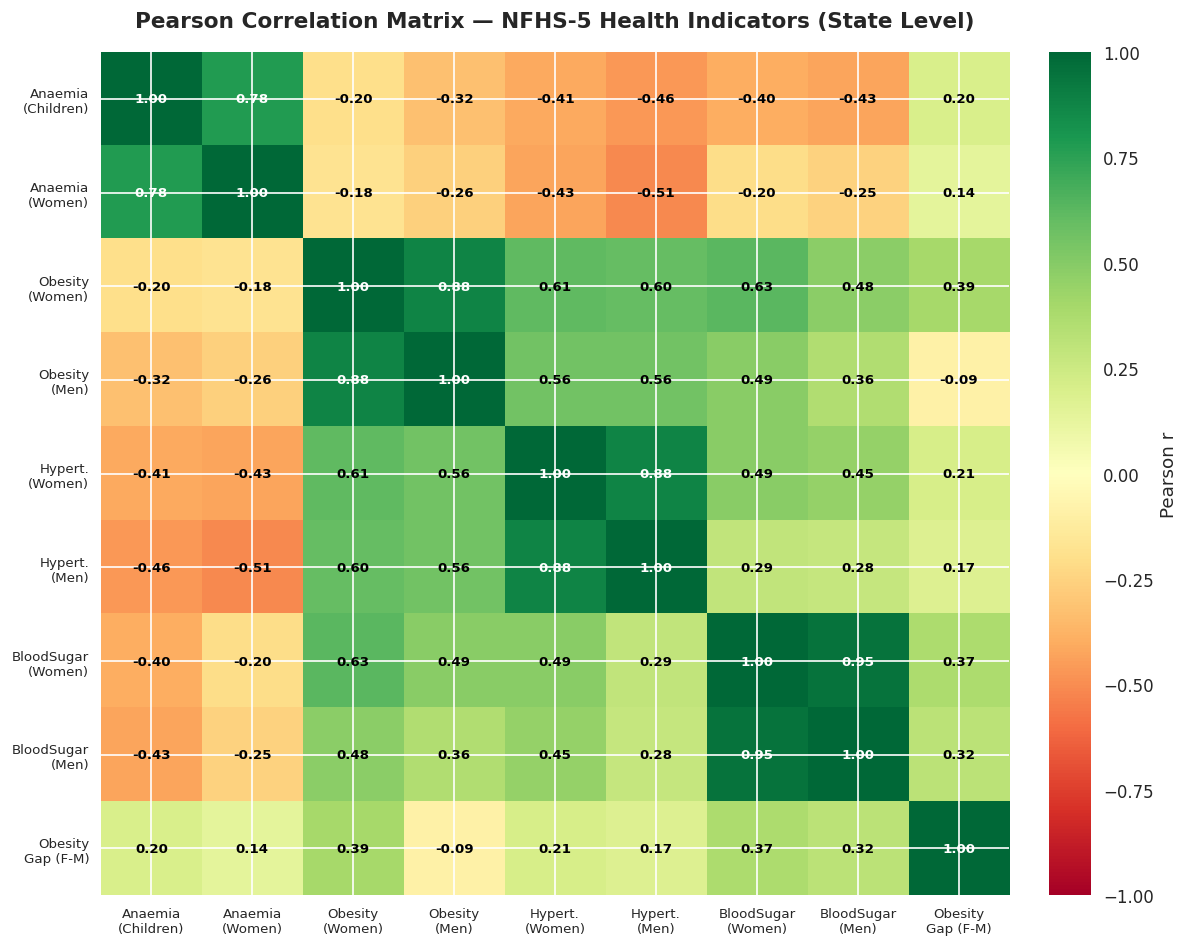


📌 Key finding: Anaemia_Children vs Obesity_Women r = -0.200


In [13]:
# ── Visualise Correlation Matrix ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))

labels = [
    'Anaemia\n(Children)', 'Anaemia\n(Women)',
    'Obesity\n(Women)', 'Obesity\n(Men)',
    'Hypert.\n(Women)', 'Hypert.\n(Men)',
    'BloodSugar\n(Women)', 'BloodSugar\n(Men)',
    'Obesity\nGap (F-M)'
]

im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')

# Annotate cells
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.values[i, j]
        color = 'white' if abs(val) > 0.7 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=8, color=color, fontweight='bold')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8, rotation=0)
ax.set_yticklabels(labels, fontsize=8)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
ax.set_title('Pearson Correlation Matrix — NFHS-5 Health Indicators (State Level)',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('phase2_task1_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Key finding: Anaemia_Children vs Obesity_Women r =",
      f"{r_anaemia_child_vs_obesity_women:.3f}")

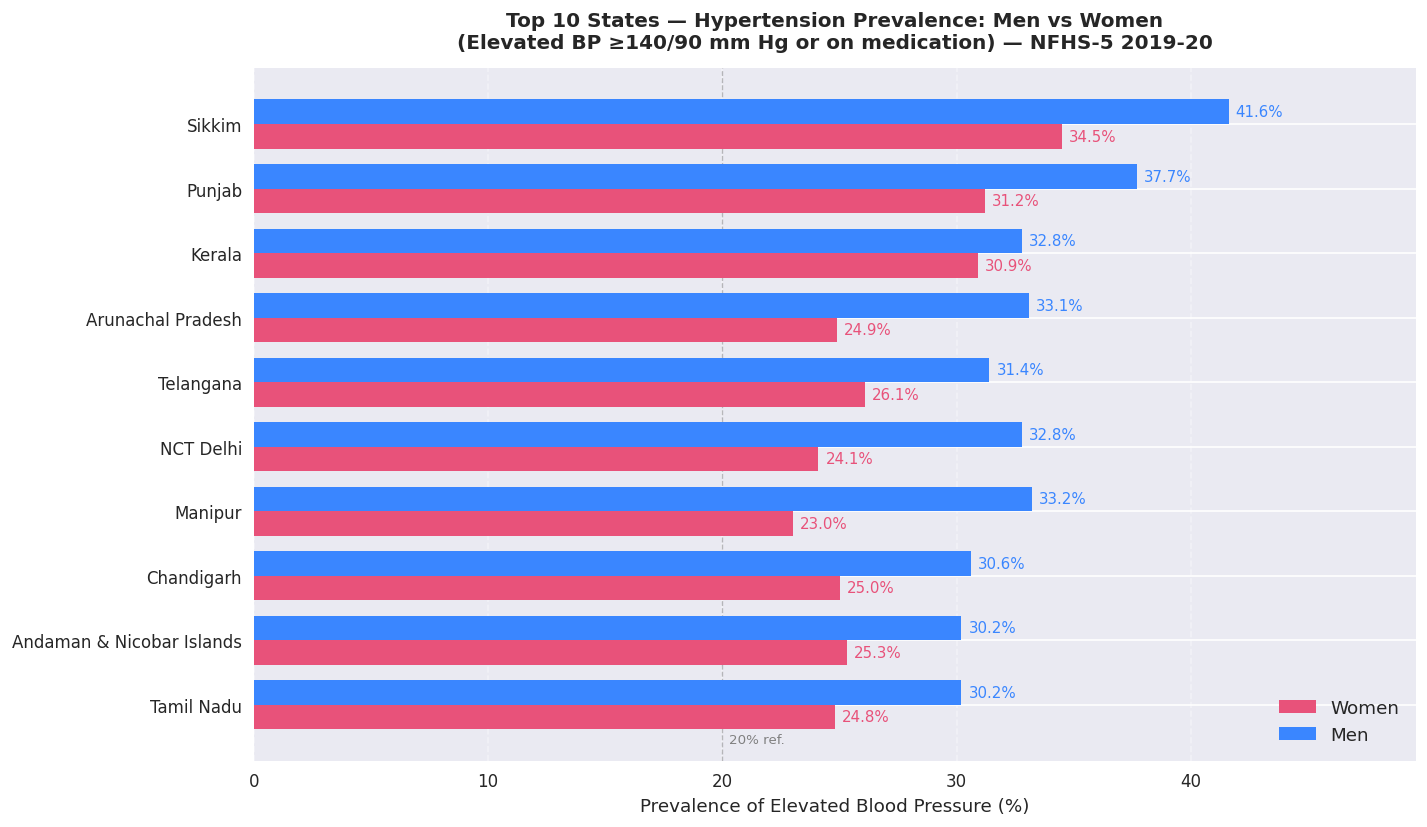

In [14]:
# ── Task 2: Top 10 States — Hypertension Men vs Women ────────────────────────
hyp_df = df[['state', 'Hypertension_Women', 'Hypertension_Men']].dropna()

hyp_df = hyp_df.copy()
hyp_df['avg_hyp'] = (hyp_df['Hypertension_Women'] + hyp_df['Hypertension_Men']) / 2
top10 = hyp_df.nlargest(10, 'avg_hyp').sort_values('avg_hyp', ascending=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(top10))
bar_width = 0.38

bars_w = ax.barh(x - bar_width/2, top10['Hypertension_Women'],
                 height=bar_width, color='#E8527A', label='Women', zorder=3)
bars_m = ax.barh(x + bar_width/2, top10['Hypertension_Men'],
                 height=bar_width, color='#3A86FF', label='Men', zorder=3)

# Data labels
for bar in bars_w:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9, color='#E8527A')
for bar in bars_m:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.1f}%', va='center', fontsize=9, color='#3A86FF')

ax.set_yticks(x)
ax.set_yticklabels(top10['state'], fontsize=10)
ax.set_xlabel('Prevalence of Elevated Blood Pressure (%)', fontsize=11)
ax.set_title(
    'Top 10 States — Hypertension Prevalence: Men vs Women\n'
    '(Elevated BP ≥140/90 mm Hg or on medication) — NFHS-5 2019-20',
    fontsize=12, fontweight='bold', pad=12
)
ax.axvline(x=20, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.text(20.3, -0.6, '20% ref.', fontsize=8, color='gray')
ax.legend(fontsize=11, loc='lower right')
ax.grid(axis='x', linestyle='--', alpha=0.4, zorder=0)
ax.set_xlim(0, max(top10[['Hypertension_Women','Hypertension_Men']].max()) + 8)

plt.tight_layout()
plt.savefig('phase2_task2_hypertension_bar.png', dpi=150, bbox_inches='tight')
plt.show()

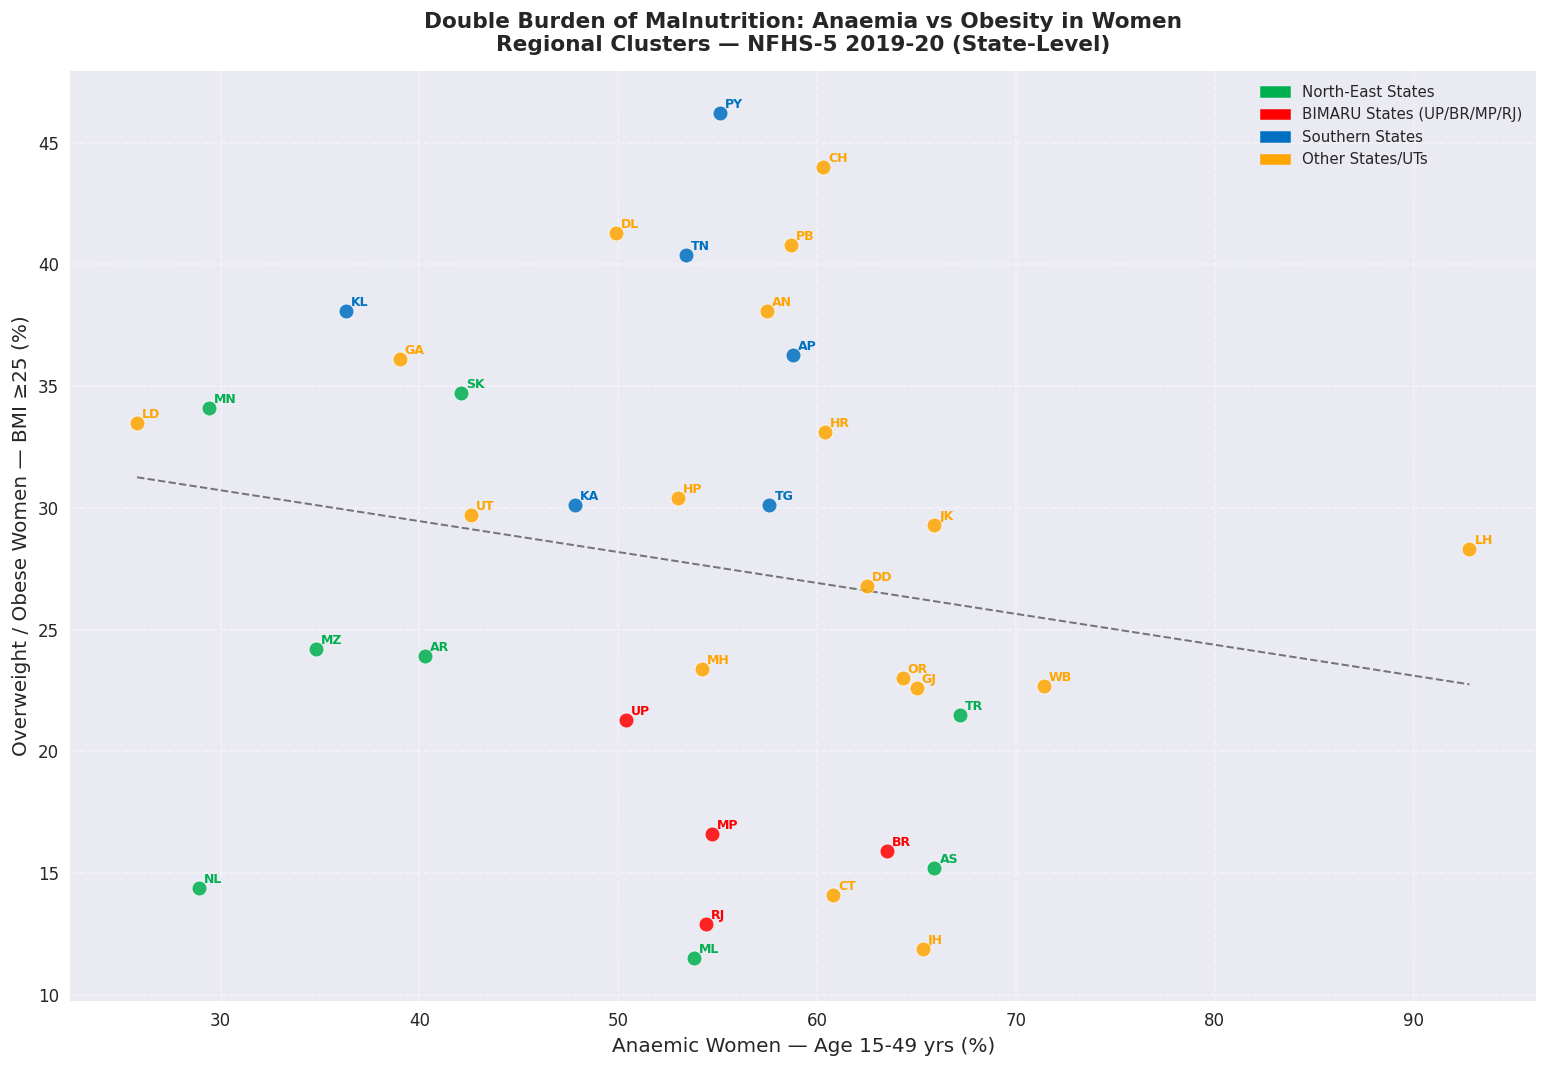


📌 Green=NE  |  Red=BIMARU  |  Blue=South  |  Orange=Others


In [15]:
# ── Task 3: Scatter — % Anaemic Women vs % Obese Women ──────────────────────
scatter_df = df[['state', 'state_code', 'Anaemia_Women', 'Obesity_Women']].dropna()

# Regional cluster colouring
NORTHEAST = {'AR','AS','ML','MN','MZ','NL','SK','TR'}
SOUTH     = {'AP','KA','KL','TN','TG','PY'}
NORTH     = {'UP','RJ','HR','PB','HP','UK','JK','LA'}
BIMARU    = {'UP','BR','MP','RJ'}

def region_color(code):
    if code in NORTHEAST: return '#00B050'
    if code in BIMARU:    return '#FF0000'
    if code in SOUTH:     return '#0070C0'
    return '#FFA500'

scatter_df = scatter_df.copy()
scatter_df['color'] = scatter_df['state_code'].apply(region_color)

fig, ax = plt.subplots(figsize=(13, 9))

for _, row in scatter_df.iterrows():
    ax.scatter(row['Anaemia_Women'], row['Obesity_Women'],
               color=row['color'], s=80, zorder=5, alpha=0.85,
               edgecolors='white', linewidths=0.5)
    ax.annotate(
        row['state_code'],
        xy=(row['Anaemia_Women'], row['Obesity_Women']),
        xytext=(3, 3), textcoords='offset points',
        fontsize=7.5, fontweight='bold', color=row['color']
    )

# OLS trend line
z = np.polyfit(scatter_df['Anaemia_Women'], scatter_df['Obesity_Women'], 1)
p = np.poly1d(z)
xs = np.linspace(scatter_df['Anaemia_Women'].min(),
                 scatter_df['Anaemia_Women'].max(), 100)
ax.plot(xs, p(xs), 'k--', linewidth=1.2, alpha=0.5, label='OLS trend')

legend_patches = [
    mpatches.Patch(color='#00B050', label='North-East States'),
    mpatches.Patch(color='#FF0000', label='BIMARU States (UP/BR/MP/RJ)'),
    mpatches.Patch(color='#0070C0', label='Southern States'),
    mpatches.Patch(color='#FFA500', label='Other States/UTs'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='upper right', framealpha=0.9)

ax.set_xlabel('Anaemic Women — Age 15-49 yrs (%)', fontsize=12)
ax.set_ylabel('Overweight / Obese Women — BMI ≥25 (%)', fontsize=12)
ax.set_title(
    'Double Burden of Malnutrition: Anaemia vs Obesity in Women\n'
    'Regional Clusters — NFHS-5 2019-20 (State-Level)',
    fontsize=13, fontweight='bold', pad=12
)
ax.grid(linestyle='--', alpha=0.35)
plt.tight_layout()
plt.savefig('phase2_task3_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n📌 Green=NE  |  Red=BIMARU  |  Blue=South  |  Orange=Others")

In [16]:
# ── Step 1: Download India GeoJSON ──────────────────────────────────────────
GEOJSON_URL = (
    "https://raw.githubusercontent.com/geohacker/india/"
    "master/state/india_state.geojson"
)
GEOJSON_FILE = "india_states.geojson"
urllib.request.urlretrieve(GEOJSON_URL, GEOJSON_FILE)

with open(GEOJSON_FILE) as f:
    geo_data = json.load(f)

print("✅ GeoJSON loaded —", len(geo_data['features']), "features")
print("Sample NAME_1 keys:", [f['properties']['NAME_1']
                               for f in geo_data['features'][:5]])

✅ GeoJSON loaded — 35 features
Sample NAME_1 keys: ['Andaman and Nicobar', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar']


In [17]:
# ── Step 2: Align GeoJSON state names with DataFrame ─────────────────────────
GEO_TO_DF = {
    'Andaman and Nicobar':    'Andaman & Nicobar Islands',
    'Andhra Pradesh':         'Andhra Pradesh',
    'Arunachal Pradesh':      'Arunachal Pradesh',
    'Assam':                  'Assam',
    'Bihar':                  'Bihar',
    'Chandigarh':             'Chandigarh',
    'Chhattisgarh':           'Chhattisgarh',
    'Dadra and Nagar Haveli': 'Dadra & Nagar Haveli and Daman & Diu',
    'Daman and Diu':          'Dadra & Nagar Haveli and Daman & Diu',
    'Delhi':                  'NCT Delhi',
    'Goa':                    'Goa',
    'Gujarat':                'Gujarat',
    'Haryana':                'Haryana',
    'Himachal Pradesh':       'Himachal Pradesh',
    'Jammu and Kashmir':      'Jammu & Kashmir',
    'Jharkhand':              'Jharkhand',
    'Karnataka':              'Karnataka',
    'Kerala':                 'Kerala',
    'Lakshadweep':            'Lakshadweep',
    'Madhya Pradesh':         'Madhya Pradesh',
    'Maharashtra':            'Maharashtra',
    'Manipur':                'Manipur',
    'Meghalaya':              'Meghalaya',
    'Mizoram':                'Mizoram',
    'Nagaland':               'Nagaland',
    'Orissa':                 'Odisha',
    'Puducherry':             'Puducherry',
    'Punjab':                 'Punjab',
    'Rajasthan':              'Rajasthan',
    'Sikkim':                 'Sikkim',
    'Tamil Nadu':             'Tamil Nadu',
    'Tripura':                'Tripura',
    'Uttar Pradesh':          'Uttar Pradesh',
    'Uttaranchal':            'Uttarakhand',
    'West Bengal':            'West Bengal',
    'Telangana':              'Telangana',
}

# Reverse map: df state → geo key
DF_TO_GEO = {v: k for k, v in GEO_TO_DF.items()}
DF_TO_GEO['Dadra & Nagar Haveli and Daman & Diu'] = 'Dadra and Nagar Haveli'

choro_df = df.copy()
choro_df['geo_key'] = choro_df['state'].map(DF_TO_GEO)
choro_df_valid = choro_df.dropna(subset=['geo_key', 'Obesity_Women'])

print("States matched to GeoJSON:", choro_df_valid.shape[0])
choro_df_valid[['state', 'geo_key', 'Obesity_Women']].head(10)

States matched to GeoJSON: 35


,state,geo_key,Obesity_Women
0,Andaman & Nicobar Islands,Andaman and Nicobar,38.1
1,Andhra Pradesh,Andhra Pradesh,36.3
2,Arunachal Pradesh,Arunachal Pradesh,23.9
3,Assam,Assam,15.2
4,Bihar,Bihar,15.9
5,Chandigarh,Chandigarh,44.0
6,Chhattisgarh,Chhattisgarh,14.1
7,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,26.8
8,Goa,Goa,36.1
9,Gujarat,Gujarat,22.6


In [18]:
# ── Step 2 cont.: Build Folium Choropleth ────────────────────────────────────
india_map = folium.Map(
    location=[20.5937, 78.9629],
    zoom_start=5,
    tiles='CartoDB positron',
    attr='CartoDB'
)

choropleth = folium.Choropleth(
    geo_data=geo_data,
    name='Women Obesity (%)',
    data=choro_df_valid,
    columns=['geo_key', 'Obesity_Women'],
    key_on='feature.properties.NAME_1',
    fill_color='YlOrRd',
    fill_opacity=0.75,
    line_opacity=0.4,
    legend_name='Women Overweight/Obese — BMI ≥25 (%) — NFHS-5 2019-20',
    nan_fill_color='#d9d9d9',
    nan_fill_opacity=0.4,
).add_to(india_map)

choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(
        fields=['NAME_1'],
        aliases=['State:'],
        style="font-size:12px; font-family:Arial;"
    )
)

print("✅ Choropleth layer added.")

✅ Choropleth layer added.


In [19]:
# ── Step 3: State Capital coordinates ────────────────────────────────────────
STATE_CAPITALS = {
    'Andhra Pradesh':       ('Amaravati',         16.5417, 80.5159),
    'Arunachal Pradesh':    ('Itanagar',           27.0844, 93.6053),
    'Assam':                ('Dispur',             26.1445, 91.7362),
    'Bihar':                ('Patna',              25.5941, 85.1376),
    'Chhattisgarh':         ('Raipur',             21.2514, 81.6296),
    'Goa':                  ('Panaji',             15.4909, 73.8278),
    'Gujarat':              ('Gandhinagar',        23.2156, 72.6369),
    'Haryana':              ('Chandigarh',         30.7333, 76.7794),
    'Himachal Pradesh':     ('Shimla',             31.1048, 77.1734),
    'Jammu & Kashmir':      ('Srinagar',           34.0837, 74.7973),
    'Jharkhand':            ('Ranchi',             23.3441, 85.3096),
    'Karnataka':            ('Bengaluru',          12.9716, 77.5946),
    'Kerala':               ('Thiruvananthapuram',  8.5241, 76.9366),
    'Madhya Pradesh':       ('Bhopal',             23.2599, 77.4126),
    'Maharashtra':          ('Mumbai',             19.0760, 72.8777),
    'Manipur':              ('Imphal',             24.8170, 93.9368),
    'Meghalaya':            ('Shillong',           25.5788, 91.8933),
    'Mizoram':              ('Aizawl',             23.7271, 92.7176),
    'Nagaland':             ('Kohima',             25.6701, 94.1077),
    'Odisha':               ('Bhubaneswar',        20.2961, 85.8245),
    'Punjab':               ('Chandigarh',         30.7333, 76.7794),
    'Rajasthan':            ('Jaipur',             26.9124, 75.7873),
    'Sikkim':               ('Gangtok',            27.3314, 88.6138),
    'Tamil Nadu':           ('Chennai',            13.0827, 80.2707),
    'Telangana':            ('Hyderabad',          17.3850, 78.4867),
    'Tripura':              ('Agartala',           23.8315, 91.2868),
    'Uttar Pradesh':        ('Lucknow',            26.8467, 80.9462),
    'Uttarakhand':          ('Dehradun',           30.3165, 78.0322),
    'West Bengal':          ('Kolkata',            22.5726, 88.3639),
    'NCT Delhi':            ('New Delhi',          28.6139, 77.2090),
    'Chandigarh':           ('Chandigarh',         30.7333, 76.7794),
    'Andaman & Nicobar Islands': ('Port Blair',    11.6234, 92.7265),
    'Puducherry':           ('Puducherry',         11.9416, 79.8083),
    'Lakshadweep':          ('Kavaratti',          10.5593, 72.6358),
    'Dadra & Nagar Haveli and Daman & Diu': ('Daman', 20.3974, 72.8328),
    'Ladakh':               ('Leh',               34.1526, 77.5770),
}

print(f"Capital coordinates defined for {len(STATE_CAPITALS)} states.")

Capital coordinates defined for 36 states.


In [20]:
# ── Step 3 cont.: Add CircleMarker layer ─────────────────────────────────────

def make_popup_html(state, capital, blood_sugar_w, blood_sugar_m,
                    anaemia_w, anaemia_c, obesity_w, obesity_m, gap):
    def fmt(val):
        return f"{val:.1f}%" if pd.notna(val) else "N/A"

    bs_avg = (blood_sugar_w + blood_sugar_m) / 2 \
             if pd.notna(blood_sugar_w) and pd.notna(blood_sugar_m) else None
    risk_color = ('#d62728' if (bs_avg and bs_avg > 15)
                  else '#ff7f0e' if (bs_avg and bs_avg > 10)
                  else '#2ca02c')

    html = f"""
    <div style="font-family:Arial,sans-serif; width:260px; padding:6px;">
      <h4 style="margin:0 0 6px 0; color:#1a1a2e;
                 border-bottom:2px solid #E63946; padding-bottom:4px;">
        📍 {state}
      </h4>
      <p style="margin:2px 0; font-size:11px; color:#555;">
        Capital: <b>{capital}</b>
      </p>

      <table style="width:100%; border-collapse:collapse;
                    margin-top:8px; font-size:11px;">
        <tr style="background:#f0f4ff;">
          <td colspan="2" style="padding:4px 6px; font-weight:bold; color:#1a1a2e;">
            🩸 High Blood Sugar (&gt;140 mg/dl or on medication)
          </td>
        </tr>
        <tr>
          <td style="padding:3px 6px; color:#555;">Women:</td>
          <td style="padding:3px 6px; font-weight:bold;
                     color:{risk_color};">{fmt(blood_sugar_w)}</td>
        </tr>
        <tr>
          <td style="padding:3px 6px; color:#555;">Men:</td>
          <td style="padding:3px 6px; font-weight:bold;
                     color:{risk_color};">{fmt(blood_sugar_m)}</td>
        </tr>

        <tr style="background:#fff8f0;">
          <td colspan="2" style="padding:4px 6px; font-weight:bold; color:#1a1a2e;">
            💉 Anaemia Rate
          </td>
        </tr>
        <tr>
          <td style="padding:3px 6px; color:#555;">Women (15-49):</td>
          <td style="padding:3px 6px; font-weight:bold;
                     color:#d62728;">{fmt(anaemia_w)}</td>
        </tr>
        <tr>
          <td style="padding:3px 6px; color:#555;">Children (6-59m):</td>
          <td style="padding:3px 6px; font-weight:bold;
                     color:#d62728;">{fmt(anaemia_c)}</td>
        </tr>

        <tr style="background:#f0fff4;">
          <td colspan="2" style="padding:4px 6px; font-weight:bold; color:#1a1a2e;">
            ⚖️ Obesity / Overweight (BMI ≥25)
          </td>
        </tr>
        <tr>
          <td style="padding:3px 6px; color:#555;">Women:</td>
          <td style="padding:3px 6px; font-weight:bold;">{fmt(obesity_w)}</td>
        </tr>
        <tr>
          <td style="padding:3px 6px; color:#555;">Men:</td>
          <td style="padding:3px 6px; font-weight:bold;">{fmt(obesity_m)}</td>
        </tr>
        <tr>
          <td style="padding:3px 6px; color:#555;">Gender Gap (F−M):</td>
          <td style="padding:3px 6px; font-weight:bold;
                     color:{'#9467bd' if pd.notna(gap) and gap > 0 else '#e377c2'};">
            {fmt(gap)}
          </td>
        </tr>
      </table>
      <p style="margin:6px 0 0 0; font-size:9px; color:#aaa;
                text-align:right;">NFHS-5 2019-20</p>
    </div>
    """
    return html


df_lookup = df.set_index('state')
marker_group = folium.FeatureGroup(name='State Capitals — Health Summary')

for state, (capital, lat, lon) in STATE_CAPITALS.items():
    if state not in df_lookup.index:
        continue

    row = df_lookup.loc[state]

    popup_html = make_popup_html(
        state         = state,
        capital       = capital,
        blood_sugar_w = row.get('BloodSugar_Women',  np.nan),
        blood_sugar_m = row.get('BloodSugar_Men',    np.nan),
        anaemia_w     = row.get('Anaemia_Women',      np.nan),
        anaemia_c     = row.get('Anaemia_Children',   np.nan),
        obesity_w     = row.get('Obesity_Women',      np.nan),
        obesity_m     = row.get('Obesity_Men',        np.nan),
        gap           = row.get('Gender_Obesity_Gap', np.nan),
    )

    bs_val = row.get('BloodSugar_Women', 10)
    bs_val = bs_val if pd.notna(bs_val) else 10
    radius = max(5, min(18, bs_val * 0.7))

    folium.CircleMarker(
        location     = [lat, lon],
        radius       = radius,
        color        = 'white',
        weight       = 1.5,
        fill         = True,
        fill_color   = '#E63946',
        fill_opacity = 0.75,
        tooltip      = folium.Tooltip(
            f"<b>{state}</b><br>Click for health summary",
            style="font-size:11px;"
        ),
        popup = folium.Popup(
            folium.Html(popup_html, script=True),
            max_width=290
        ),
    ).add_to(marker_group)

marker_group.add_to(india_map)
folium.LayerControl(collapsed=False).add_to(india_map)

print("✅ CircleMarker layer added for", len(STATE_CAPITALS), "state capitals.")
print("   Circle radius ∝ Women's Blood Sugar Rate")

✅ CircleMarker layer added for 36 state capitals.
   Circle radius ∝ Women's Blood Sugar Rate


In [21]:
# ── Save and display the Folium map ─────────────────────────────────────────
MAP_FILE = 'nfhs5_india_health_map.html'
india_map.save(MAP_FILE)
print(f"✅ Interactive map saved → {MAP_FILE}")
print("   Open this file in your browser to explore.")

# Display inline in Jupyter
from IPython.display import IFrame
IFrame(MAP_FILE, width='100%', height=580)

✅ Interactive map saved → nfhs5_india_health_map.html
   Open this file in your browser to explore.
